### **Hypothetical Business Case**:

The real estate agency, N_Move-in Realtors, gathered data from the previous year to analyze a newly developed area in Wellinborough, Northampton. With the objective of predicting house prices, this data was collected to provide valuable insights to landlords seeking to determine the market value of their properties for potential buyers. As the newly appointed data scientist, my task was to develop a model capable of accurately predicting house prices based on key features such as house age, distance to convenience stores, and distance to the nearest MRT station.

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [23]:
import sklearn; print(sklearn.__version__)

1.6.1


In [2]:
df = pd.read_csv(r".\Real estate.csv")

In [3]:
df.head()

,No,X1 transaction date,X2 house age,X3 distance to the nearest MRT station,X4 number of convenience stores,X5 latitude,X6 longitude,Y house price of unit area
0,1,2012.917,32.0,84.87882,10,24.98298,121.54024,37.9
1,2,2012.917,19.5,306.59470,9,24.98034,121.53951,42.2
2,3,2013.583,13.3,561.98450,5,24.98746,121.54391,47.3
3,4,2013.500,13.3,561.98450,5,24.98746,121.54391,54.8
4,5,2012.833,5.0,390.56840,5,24.97937,121.54245,43.1


### **Data Cleaning & Exploration**

In [4]:
df.drop(columns=['No','X1 transaction date','X5 latitude', 'X6 longitude' ], inplace=True)

In [5]:
df.rename(columns={'X2 house age':'house_age','X3 distance to the nearest MRT station': 'dist_to_train_station','X4 number of convenience stores':'num_con_store', 'Y house price of unit area':'house_price'}, inplace=True)

In [6]:
df.head()

,house_age,dist_to_train_station,num_con_store,house_price
0,32.0,84.87882,10,37.9
1,19.5,306.59470,9,42.2
2,13.3,561.98450,5,47.3
3,13.3,561.98450,5,54.8
4,5.0,390.56840,5,43.1


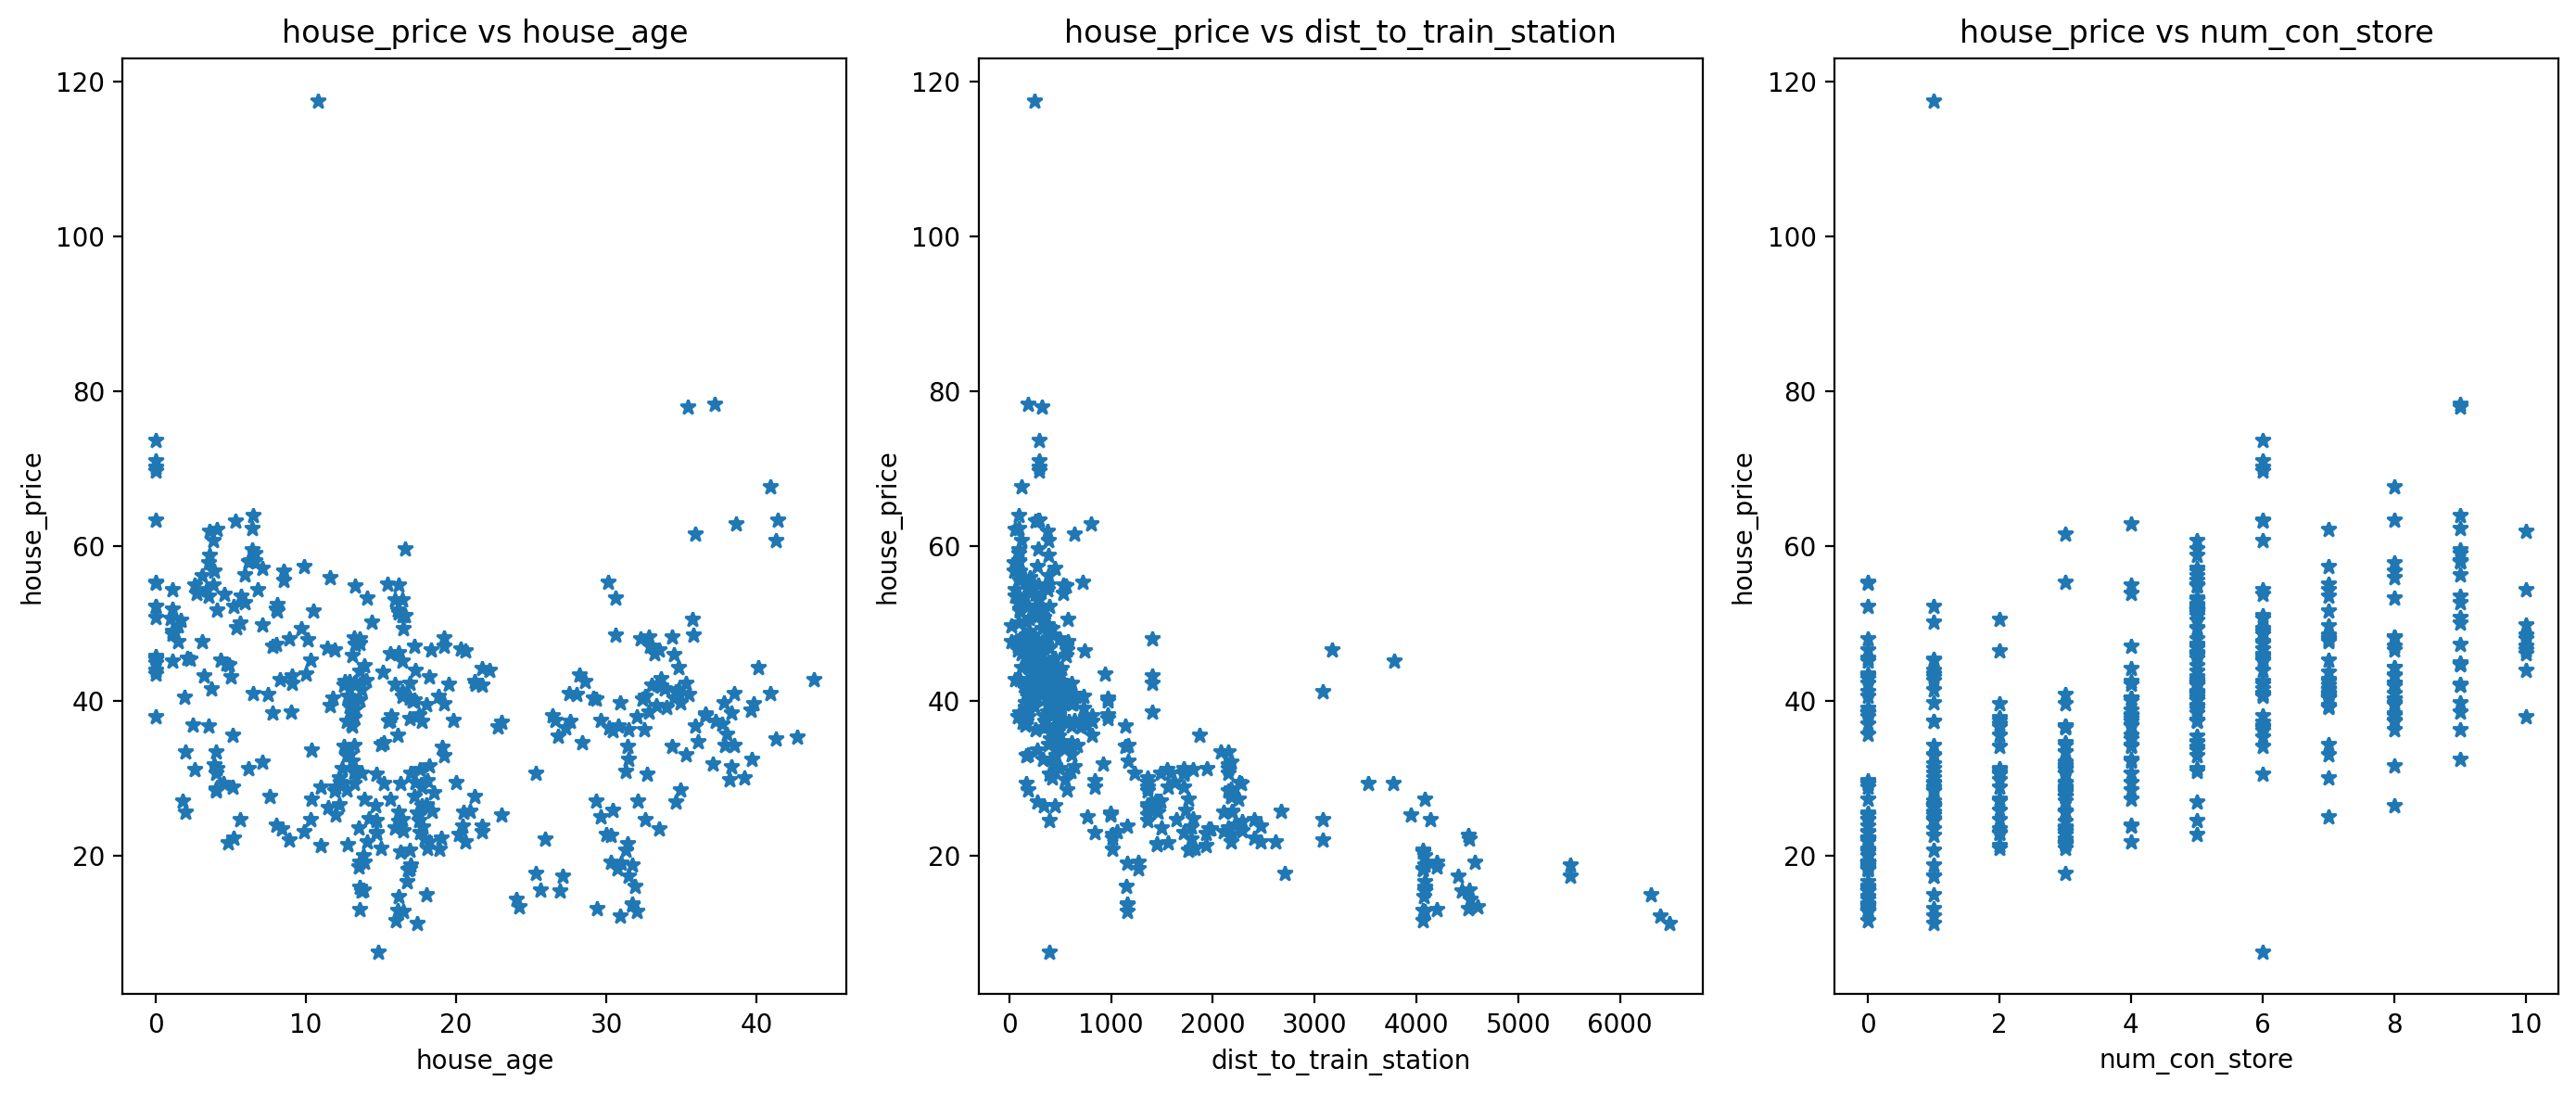

In [7]:
fig, ax = plt.subplots(nrows=1, ncols=3, figsize=(14, 6), dpi=200)

ax[0].plot(df['house_age'], df['house_price'], '*')
ax[0].set_xlabel('house_age')
ax[0].set_ylabel('house_price')
ax[0].set_title('house_price vs house_age')


ax[1].plot(df['dist_to_train_station'], df['house_price'], '*')
ax[1].set_xlabel('dist_to_train_station')
ax[1].set_ylabel('house_price')
ax[1].set_title('house_price vs dist_to_train_station')


ax[2].plot(df['num_con_store'], df['house_price'], '*')
ax[2].set_xlabel('num_con_store')
ax[2].set_ylabel('house_price')
ax[2].set_title('house_price vs num_con_store')

plt.tight_layout()
plt.show()

**Notes:**

- From the above, distance to nearest train station has a strong inverse relationship to the price; the lower the distance the higher the price.
- From the above, the age of the house seem to have no strong effect on the house price
- The number of conveninece stores have a positive relationship with the house price; the more the conveniences stores, the higher the price.

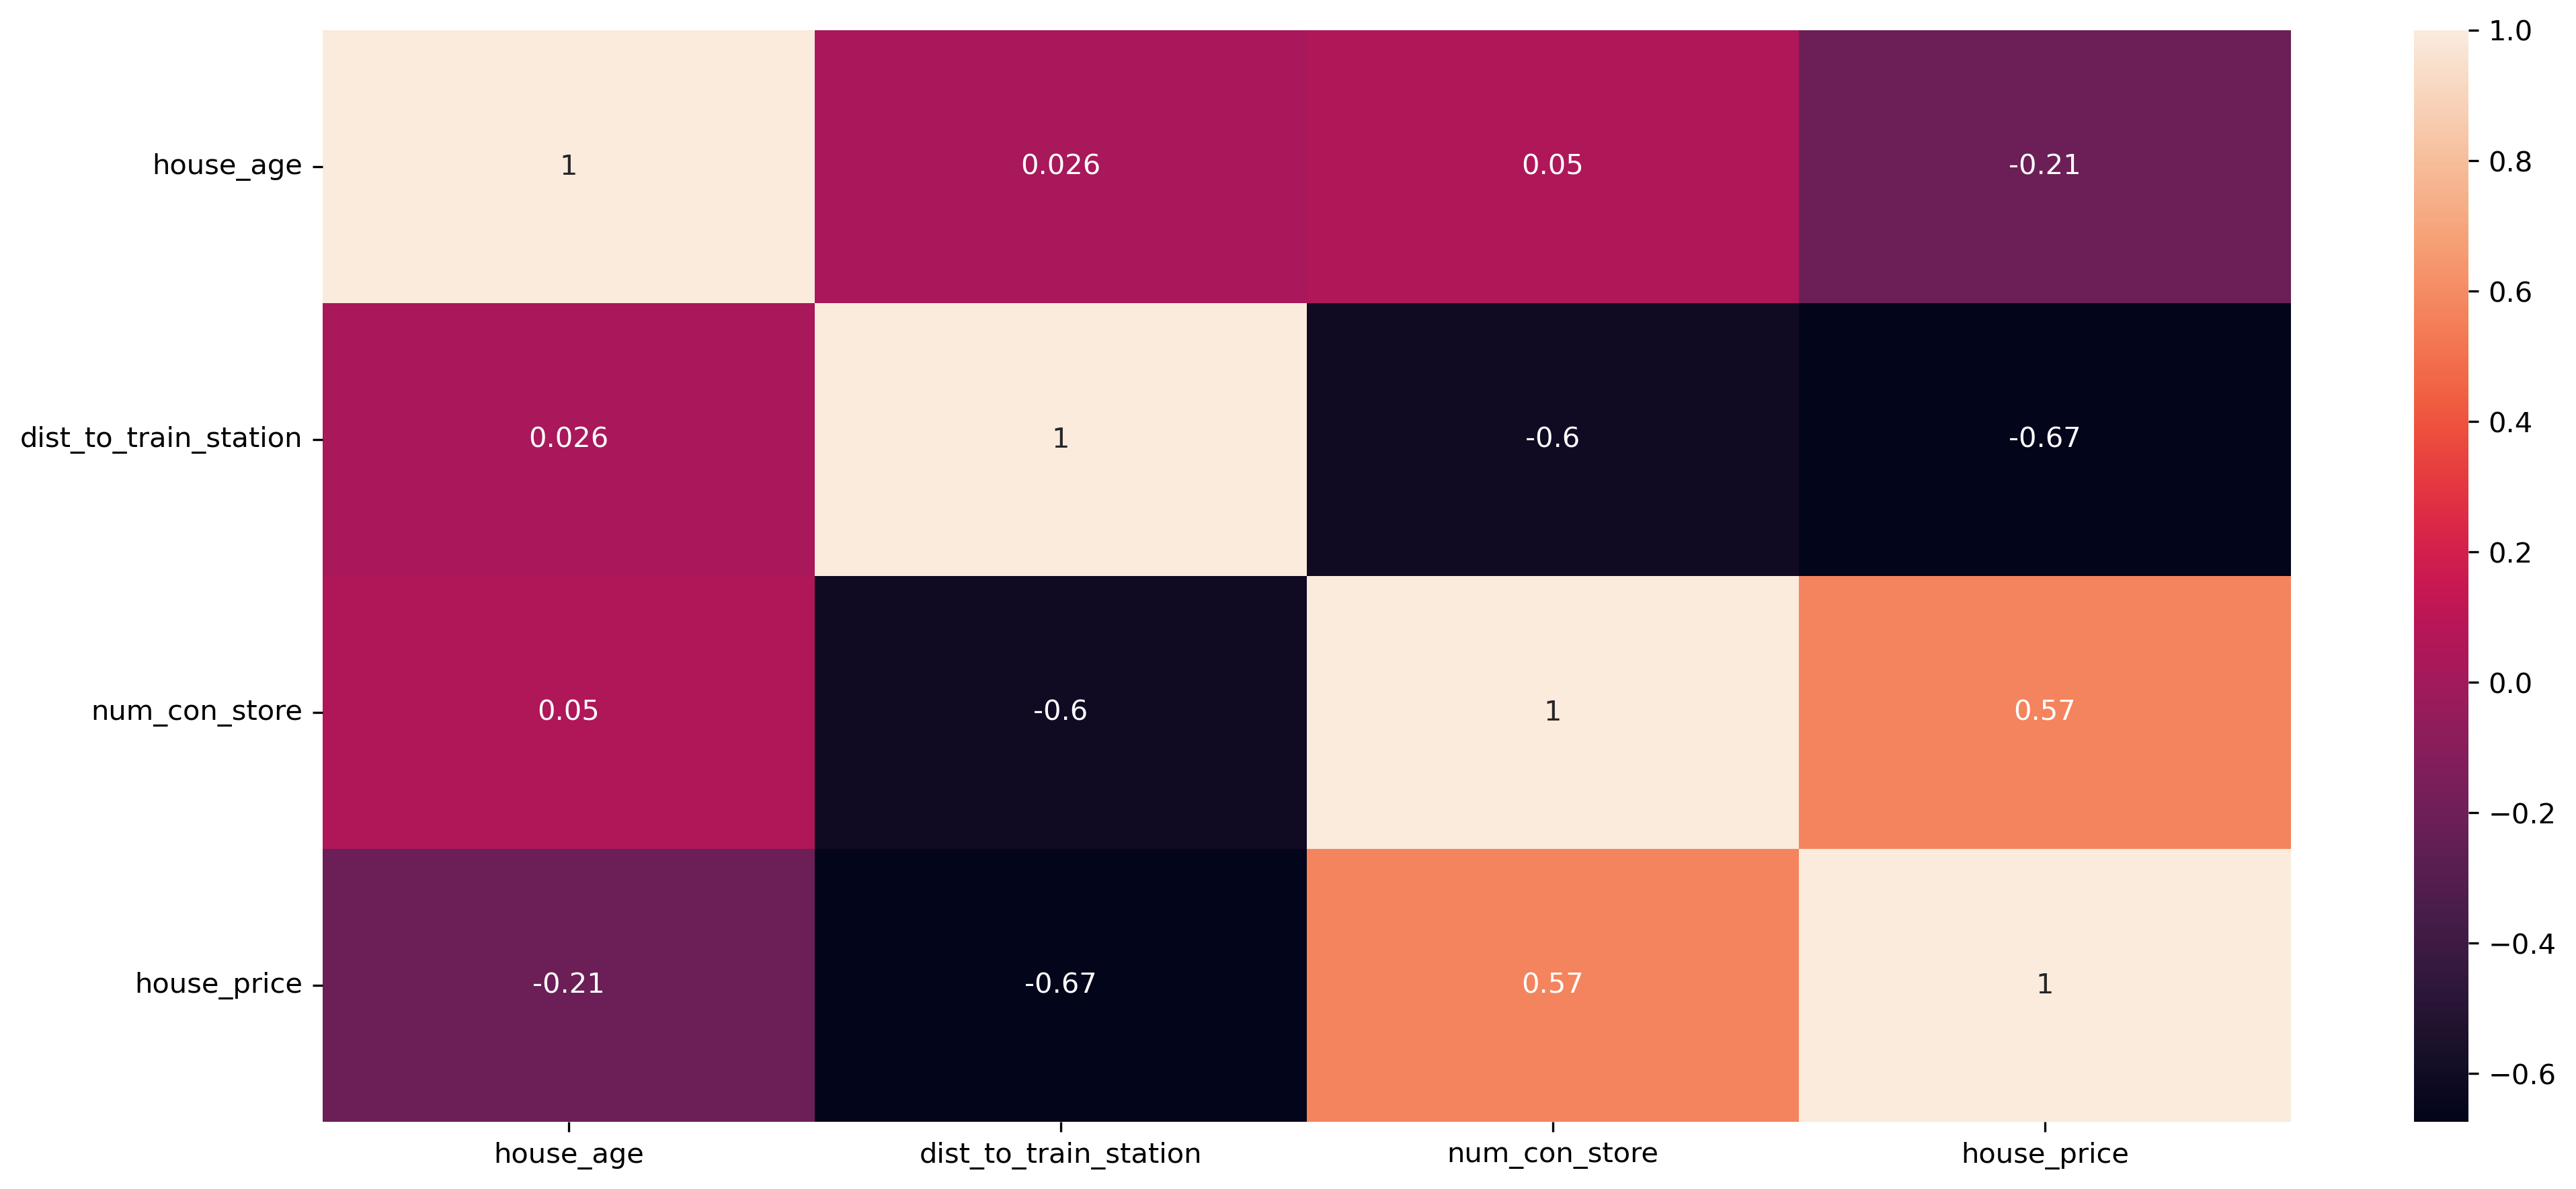

In [8]:
plt.figure(figsize=(14,6), dpi=300)

sns.heatmap(df.corr(), annot=True)

plt.tight_layout()
plt.show()

**Notes**:

From the heatmap correlation diagram:
- the higher the distance to the train station}, the lower the price. There's an inverse relationship. Hence, it's negative. *__(Far Train Station = Less Pricey)__*
- The age of the hosue seems to follow in an inverse relationship pattern with the price of the house; the higher the age, the lower the price. This could be because new houses come with modernized house equipment anmd designs than the older houses. *__(Older Houses= Less Pricey)__*
- The number of convenience stores have a positive relationship; the more the convenience stores- the higher the price. *__(More stores = pricier)__*

## **Define & Split the dataset**

In [9]:
X= df.drop('house_price', axis=1)

y= df['house_price']

#### Train|Test|Split

In [10]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

#### Data Dimension

In [11]:
X_train.shape

# # 80%

(331, 3)

In [12]:
X_test.shape

# # 20%

(83, 3)

### **Scaling**

In [13]:
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, RidgeCV

models = {
    'Linear Regression': make_pipeline(StandardScaler(), LinearRegression()),
    'Ridge Regression': make_pipeline(StandardScaler(), Ridge()),
    'RidgeCV Regression': make_pipeline(StandardScaler(), RidgeCV())
}   


## **Models**

### Linear Regression Model

In [14]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=30)

from sklearn.linear_model import LinearRegression

lin_model = LinearRegression()

lin_model.fit(X_train, y_train)

y_pred = lin_model.predict(X_test)

# Metrics

from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)
coef = lin_model.coef_

print('Using Linear Regression:\n\nthe MAE is:', mae, '\nthe RMSE is:', rmse, '\nthe R2 score is:', r2, '\nthe Coef is:', coef)

Using Linear Regression:

the MAE is: 7.1342806164245 
the RMSE is: 9.983424849795908 
the R2 score is: 0.4534255433018419 
the Coef is: [-0.27060981 -0.00550487  1.17473128]


### Ridge Regression (L2 Regularization)

In [15]:
from sklearn.linear_model import Ridge

ridge_model = Ridge(alpha=0.5)

ridge_model.fit(X_train, y_train)

y_pred = ridge_model.predict(X_test)

# Metrics

from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)
coef = ridge_model.coef_

print('Using Ridge Regression at Alpha 0.5:\n\nthe MAE is:', mae, '\nthe RMSE is:', rmse, '\nthe R2 score is:', r2, '\nthe Coef is:', coef)

Using Ridge Regression at Alpha 0.5:

the MAE is: 7.134318591690922 
the RMSE is: 9.983536627340133 
the R2 score is: 0.4534133039965046 
the Coef is: [-0.27060287 -0.00550532  1.17439856]


#### Ridge Regression (Alpha-.001)

In [16]:
ridge_model_2 = Ridge(alpha=0.0001)
# Can't use solcing for Ridge Regression- only for Ridge CV

ridge_model_2.fit(X_train, y_train)

y_pred = ridge_model_2.predict(X_test)

# Metrics

from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)
coef = ridge_model_2.coef_

print('Using Ridge Regression at Alpha .001:\n\nthe MAE is:', mae, '\nthe RMSE is:', rmse, '\nthe R2 score is:', r2, '\nthe Coef is:', coef)

Using Ridge Regression at Alpha .001:

the MAE is: 7.134280624021592 
the RMSE is: 9.983424872151428 
the R2 score is: 0.4534255408539932 
the Coef is: [-0.27060981 -0.00550487  1.17473122]


#### Ridge Regression (Alpha-0.0)

In [17]:
ridge_model_3 = Ridge(alpha=0.0)

ridge_model_3.fit(X_train, y_train)

y_pred = ridge_model_3.predict(X_test)

# Metrics

from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
coef = ridge_model_3.coef_
r2 = r2_score(y_test, y_pred)

print('Using Ridge Regression at Alpha 0.0:\n\nthe MAE is:', mae, '\nthe RMSE is:', rmse, '\nthe R2 score is:', r2, '\nthe Coef is:', coef)

Using Ridge Regression at Alpha 0.0:

the MAE is: 7.134280616424499 
the RMSE is: 9.983424849795906 
the R2 score is: 0.45342554330184204 
the Coef is: [-0.27060981 -0.00550487  1.17473128]


### Ridge CV

In [18]:
from sklearn.linear_model import RidgeCV

ridgecv_model = RidgeCV(alphas=(0.005, 0.00005, 0.001), scoring = 'neg_mean_absolute_error')

ridgecv_model.fit(X_train, y_train)

y_pred = ridgecv_model.predict(X_test)

# Metrics

from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
residual= y_test-y_pred

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)
coef = ridgecv_model.coef_

print('Using Ridge Regression CV at an optimal alpha .005:\n\nthe MAE is:', mae, '\nthe RMSE is:', rmse, '\nthe R2 score is:', r2, '\nthe Coef is:', coef)

Using Ridge Regression CV at an optimal alpha .005:

the MAE is: 7.135923911757575 
the RMSE is: 9.985483390153268 
the R2 score is: 0.4532001173394098 
the Coef is: [-0.27060958 -0.00545597  1.17473116]


In [19]:
ridgecv_model.alpha_

5e-05

In [20]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np, pandas as pd

rows = []
for name, model in models.items():
    model.fit(X_train, y_train)
    pred = model.predict(X_test)
    rows.append({
        "Model": name,
        "MAE":  mean_absolute_error(y_test, pred),
        "RMSE": np.sqrt(mean_squared_error(y_test, pred)),
        "R2":   r2_score(y_test, pred),
    })

print(pd.DataFrame(rows).set_index("Model").round(3))

                      MAE   RMSE     R2
Model                                  
Linear Regression   7.134  9.983  0.453
Ridge Regression    7.135  9.983  0.454
RidgeCV Regression  7.143  9.979  0.454


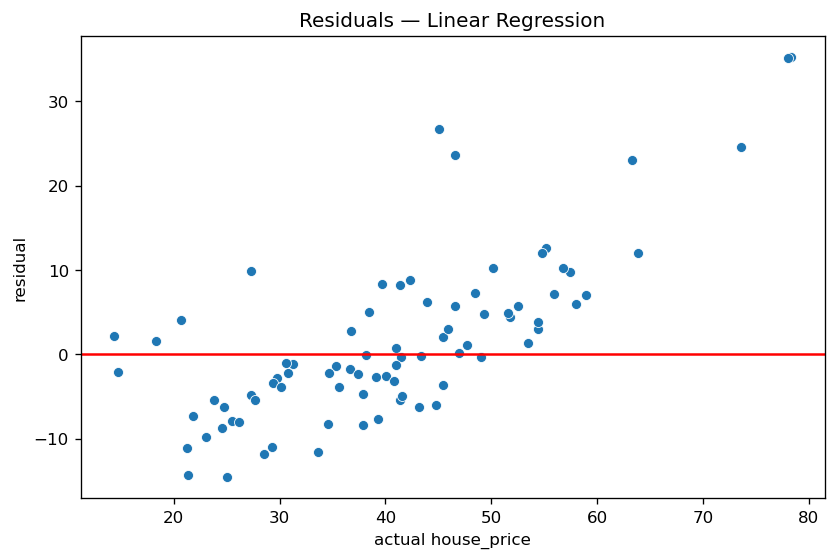

In [21]:
best_name = "Linear Regression"
pred = models[best_name].predict(X_test)
residual = y_test - pred

plt.figure(figsize=(8, 5), dpi=120)
sns.scatterplot(x=y_test, y=residual)
plt.axhline(y=0, color='red')
plt.xlabel("actual house_price"); plt.ylabel("residual"); plt.title(f"Residuals — {best_name}")
plt.show()
# Even band around 0 = homoskedastic (good).  Fan/cone shape = heteroskedastic.

## **Deploy**

**Linear Regression won** (lowest MAE; the models are tied to the third decimal, so we pick the
simplest — parsimony). Refit the winner on **all** the data, then save. Because the scaler lives
*inside* the pipeline, the saved file already knows how to scale whatever a user types in — no manual
scaling anywhere.

In [22]:
from joblib import dump, load

#Linear model won with the lowest MSE. More so,m the 'Parsimonmmy' Lasw states use the simplest model- if models are tied.
best = models["Linear Regression"]   

best.fit(X, y)            #refitting the best model on the full dataset   
dump(best, "house_model.joblib") #the scale lives inside the pipeline, so it scales too

#sanity check: reload and confirm it works
reloaded_model = load("house_model.joblib")
print("Saved & reloaded OK")
print("Scaled coefficients:", reloaded_model.named_steps["linearregression"].coef_)
print("Feature order:", list(X.columns))


Saved & reloaded OK
Scaled coefficients: [-2.87717494 -6.78084682  3.81707864]
Feature order: ['house_age', 'dist_to_train_station', 'num_con_store']


- The coefficients above, in order, represents:
    - -2.87717494; an inverse relationship between the houser age and the house price. Modern houses are gaining more popularity thanh older houses. The data must have more older houses or older aged houses for the relationship to be established as inverse
    - -6.78084682; the inverse relationship between house proce and the distance to train stations. the higher the distance, the lower the house price.
    - 3.81707864: The higher the number of convenience stores, the higher the hiuse price- esatbliushing a positive relktionship.


#### **Conclusion with Model Caveats:**

All three models landed within a fraction of a point of each other on the same held-out test set
(MAE ≈ 7.13, RMSE ≈ 9.98, R² ≈ 0.45). Linear Regression had the lowest MAE, and because Ridge and
RidgeCV offered no meaningful improvement, the simplest model was selected on the principle of
**parsimony** — when models are statistically tied, the simpler one is preferred: easier to interpret,
faster, and less prone to overfitting. Ridge and RidgeCV still earned their place as a *check* — they
confirmed the data wasn't suffering from harmful multicollinearity that regularisation needed to tame.

The model's ability to accurately predict house prices relies on the assumption that the selected features—house age, distance to convenience stores, and distance to the nearest MRT station—retain their significance in today's real estate context. Given the dynamic nature of the housing market, changes in economic conditions, urban development, and societal preferences may have altered the relevance of these features over time.

Furthermore, while the model identifies significant relationships between the chosen features and house prices, it's essential to recognize the potential existence of other unexplored variables that could exert a stronger influence on property values. These unaccounted-for factors may possess considerable predictive power and could significantly impact house prices in ways not captured by the model.

Continued monitoring of market trends and consideration of additional influential factors will be used as the market evolves.